In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn

In [2]:
from vaccination_functions import *
from acs_data_functions import *

In [3]:
tx_mmr_vac_rates = pd.read_csv("../TX_MMR_vax_rate_24_25.csv")
counties_with_vac = tx_mmr_vac_rates['County'].unique()

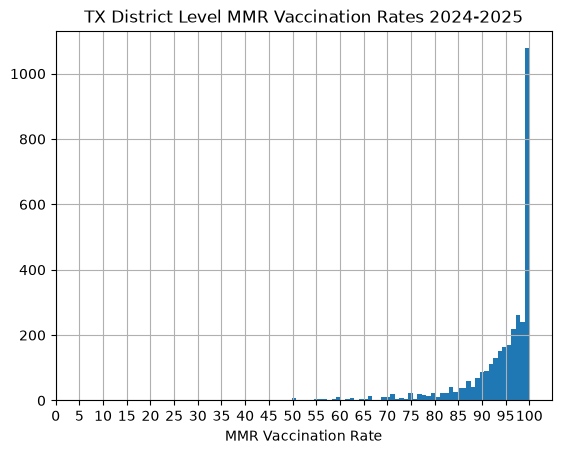

In [9]:
plt.hist(tx_mmr_vac_rates['MMR Vaccination Rate'], bins=100)
plt.xlabel('MMR Vaccination Rate')
plt.title('TX District Level MMR Vaccination Rates 2024-2025')
plt.grid()
custom_x_ticks = np.arange(0, 101, 5)
#plt.xlim(5, 101)
plt.xticks(custom_x_ticks)
plt.savefig('../plots/tx_mmr_vac_rates_24_25_district_level.png', bbox_inches="tight")

In [8]:
#tx_mmr_vac_rates['Percentiles'] =  tx_mmr_vac_rates['MMR Vaccination Rate'].quantile([0.25, 0.50, 0.75, 0.90, 0.95])
#tx_mmr_vac_rates['Percentiles']
tx_mmr_vac_rates['MMR Vaccination Rate'].quantile([0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75])

0.01     53.1038
0.05     74.4880
0.10     83.3300
0.15     87.5000
0.20     90.0000
0.25     91.6700
0.50     96.7700
0.55     97.4120
0.60     98.0400
0.65     98.6100
0.70     99.5080
0.75    100.0000
Name: MMR Vaccination Rate, dtype: float64

In [12]:
acs_data_path = "../acs_data/"

disability_df = pd.read_csv(acs_data_path+"tx_county_disability_24.csv")
disability_var_df = pd.read_csv(acs_data_path+"disabilityVars_acs.csv")

language_df = pd.read_csv(acs_data_path+"tx_county_language_24.csv")
language_var_df = pd.read_csv(acs_data_path+"languageVars_acs.csv")

health_insurance_df = pd.read_csv(acs_data_path+"tx_county_health_insurance_24.csv")
health_insurance_var_df = pd.read_csv(acs_data_path+"healthInsurVars_acs.csv")

In [15]:
disability_with_var_all, disability_with_var_no_gender = create_predictor_datasets(disability_df, disability_var_df, counties_with_vac)
language_with_var_all, language_with_var_no_gender = create_predictor_datasets(language_df, language_var_df, counties_with_vac)
health_insurance_with_var_all, health_insurance_with_var_no_gender = create_predictor_datasets(health_insurance_df, health_insurance_var_df, counties_with_vac)

In [30]:
disability_with_var_all.columns = disability_with_var_all.columns.str.replace({'_Sex_by_Age_by_Disability_Status': ''}, regex=True)
health_insurance_with_var_all.columns = health_insurance_with_var_all.columns.str.replace({'_Health_Insurance_Coverage_Status_by_Sex_by_Age': ''}, regex=True)
language_with_var_all.columns = language_with_var_all.columns.str.replace({'_Detailed_Household_Language_by_Household_Limited_English_Speaking_Status': ''}, regex=True)

In [25]:
disability_percent = pd.DataFrame()
disability_total = disability_with_var_all['Estimate_Total']

disability_percent['Percent_Under_5_with_disability'] = (disability_with_var_all['Estimate_Total_Male_Under_5_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_Under_5_With_a_disability'])/disability_total
disability_percent['Percent_Under_5_no_disability'] = (disability_with_var_all['Estimate_Total_Male_Under_5_No_disability']+ disability_with_var_all['Estimate_Total_Female_Under_5_No_disability'])/disability_total
disability_percent['Percent_5_17_with_disability'] = (disability_with_var_all['Estimate_Total_Male_5_17_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_5_17_With_a_disability'])/disability_total
disability_percent['Percent_5_17_no_disability'] = (disability_with_var_all['Estimate_Total_Male_5_17_No_disability']+ disability_with_var_all['Estimate_Total_Female_5_17_No_disability'])/disability_total
disability_percent['Percent_18_34_with_disability'] = (disability_with_var_all['Estimate_Total_Male_18_34_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_18_34_With_a_disability'])/disability_total
disability_percent['Percent_18_34_no_disability'] = (disability_with_var_all['Estimate_Total_Male_18_34_No_disability']+ disability_with_var_all['Estimate_Total_Female_18_34_No_disability'])/disability_total
disability_percent['Percent_35_64_with_disability'] = (disability_with_var_all['Estimate_Total_Male_35_64_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_35_64_With_a_disability'])/disability_total
disability_percent['Percent_35_64_no_disability'] = (disability_with_var_all['Estimate_Total_Male_35_64_No_disability']+ disability_with_var_all['Estimate_Total_Female_35_64_No_disability'])/disability_total
disability_percent['Percent_65_74_with_disability'] = (disability_with_var_all['Estimate_Total_Male_65_74_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_65_74_With_a_disability'])/disability_total
disability_percent['Percent_65_74_no_disability'] = (disability_with_var_all['Estimate_Total_Male_65_74_No_disability']+ disability_with_var_all['Estimate_Total_Female_65_74_No_disability'])/disability_total
disability_percent['Percent_75_and_over_with_disability'] = (disability_with_var_all['Estimate_Total_Male_75_and_over_With_a_disability']+ disability_with_var_all['Estimate_Total_Female_75_and_over_With_a_disability'])/disability_total
disability_percent['Percent_75_and_over_no_disability'] = (disability_with_var_all['Estimate_Total_Male_75_and_over_No_disability']+ disability_with_var_all['Estimate_Total_Female_75_and_over_No_disability'])/disability_total


In [33]:
health_insurance_percent = pd.DataFrame()
health_insurance_total = health_insurance_with_var_all['Estimate_Total']

health_insurance_percent['Percent_Under_6_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_Under_6_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_Under_6_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_Under_6_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_Under_6_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_Under_6_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_6_18_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_6_18_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_6_18_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_6_18_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_6_18_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_6_18_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_19_25_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_19_25_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_19_25_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_19_25_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_19_25_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_19_25_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_26_34_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_26_34_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_26_34_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_26_34_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_26_34_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_26_34_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_35_44_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_35_44_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_35_44_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_35_44_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_35_44_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_35_44_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_45_54_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_45_54_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_45_54_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_45_54_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_45_54_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_45_54_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_55_64_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_55_64_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_55_64_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_55_64_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_55_64_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_55_64_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_65_74_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_65_74_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_65_74_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_65_74_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_65_74_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_65_74_No_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_75_and_over_with_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_75_and_over_With_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_75_and_over_With_health_insurance_coverage'])/health_insurance_total
health_insurance_percent['Percent_75_and_over_no_health_insurance'] = (health_insurance_with_var_all['Estimate_Total_Male_75_and_over_No_health_insurance_coverage']+ health_insurance_with_var_all['Estimate_Total_Female_75_and_over_No_health_insurance_coverage'])/health_insurance_total

In [36]:
language_with_var_all.columns

Index(['Estimate_Total_Arabic',
       'Estimate_Total_Arabic_Limited_English_speaking_household',
       'Estimate_Total_Arabic_Not_a_limited_English_speaking_household',
       'Estimate_Total_Chinese_(incl._Mandarin,_Cantonese)',
       'Estimate_Total_Chinese_(incl._Mandarin,_Cantonese)_Limited_English_speaking_household',
       'Estimate_Total_Chinese_(incl._Mandarin,_Cantonese)_Not_a_limited_English_speaking_household',
       'Estimate_Total', 'Estimate_Total_English_only',
       'Estimate_Total_French,_Haitian,_or_Cajun',
       'Estimate_Total_French,_Haitian,_or_Cajun_Limited_English_speaking_household',
       'Estimate_Total_French,_Haitian,_or_Cajun_Not_a_limited_English_speaking_household',
       'Estimate_Total_German_or_other_West_Germanic_languages',
       'Estimate_Total_German_or_other_West_Germanic_languages_Limited_English_speaking_household',
       'Estimate_Total_German_or_other_West_Germanic_languages_Not_a_limited_English_speaking_household',
       'Estim

In [40]:
language_percent = pd.DataFrame()
language_total = language_with_var_all['Estimate_Total']

language_percent['Percent_Limited_English_speaking_household'] = (language_with_var_all['Estimate_Total_Vietnamese_Limited_English_speaking_household'] 
                                                                + language_with_var_all['Estimate_Total_Tagalog_(incl._Filipino)_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Spanish_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Russian,_Polish,_or_other_Slavic_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_and_unspecified_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Indo-European_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Asian_and_Pacific_Island_languages_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Chinese_(incl._Mandarin,_Cantonese)_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_French,_Haitian,_or_Cajun_Limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_German_or_other_West_Germanic_languages_Limited_English_speaking_household']    
                                                                + language_with_var_all['Estimate_Total_Arabic_Limited_English_speaking_household']   
                                                                + language_with_var_all['Estimate_Total_Korean_Limited_English_speaking_household'])/language_total

language_percent['Percent_Not_a_limited_English_speaking_household'] = (language_with_var_all['Estimate_Total_Vietnamese_Not_a_limited_English_speaking_household'] 
                                                                + language_with_var_all['Estimate_Total_Tagalog_(incl._Filipino)_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Spanish_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Russian,_Polish,_or_other_Slavic_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_and_unspecified_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Indo-European_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Other_Asian_and_Pacific_Island_languages_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_Chinese_(incl._Mandarin,_Cantonese)_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_French,_Haitian,_or_Cajun_Not_a_limited_English_speaking_household']
                                                                + language_with_var_all['Estimate_Total_German_or_other_West_Germanic_languages_Not_a_limited_English_speaking_household']    
                                                                + language_with_var_all['Estimate_Total_Arabic_Not_a_limited_English_speaking_household']   
                                                                + language_with_var_all['Estimate_Total_Korean_Not_a_limited_English_speaking_household'])/language_total

language_percent['Percent_English_only_speaking_household'] = language_with_var_all['Estimate_Total_English_only']/language_total